Umbralizacion Binaria y Binaria Inversa

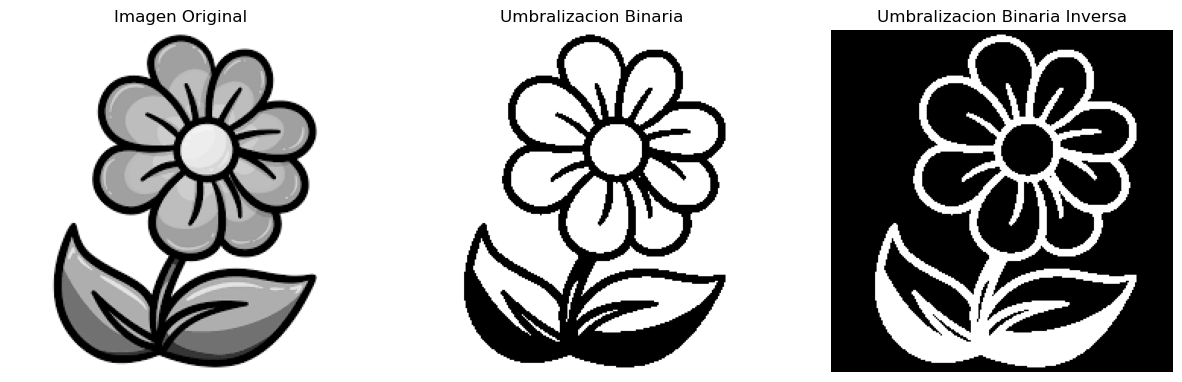

In [1]:
import cv2
import matplotlib.pyplot as plt
imagen = cv2.imread('flor.jpg',0) #lo lee en escala de grises (se puede usar color to gray)
#umbralizacion binaria
_,umbral_binario = cv2.threshold(imagen,127,255,cv2.THRESH_BINARY) #devulve dos valores metricas y la imagen umbralizada
#umbralizacion binaria inversa
_,umbral_binaria_inv = cv2.threshold(imagen,127,255,cv2.THRESH_BINARY_INV)

plt.figure(figsize=(15,5))
#imagen original
plt.subplot(1,3,1)
plt.imshow(imagen,cmap='gray')
plt.title('Imagen Original')
plt.axis('off')
#umbralizacion binaria
plt.subplot(1,3,2)
plt.imshow(umbral_binario,cmap='gray')
plt.title('Umbralizacion Binaria')
plt.axis('off')
#umbralizacion binaria inversa
plt.subplot(1,3,3)
plt.imshow(umbral_binaria_inv,cmap='gray')
plt.title('Umbralizacion Binaria Inversa')
plt.axis('off')
plt.show()

Filtro Bayer

es el patrón de colores que usan la mayoría de sensores: cada píxel captura solo R, G o B. Se aplica para "simular" cómo el sensor ve los colores (mosaico CFA) y luego reconstruir la imagen a color mediante demosaicing

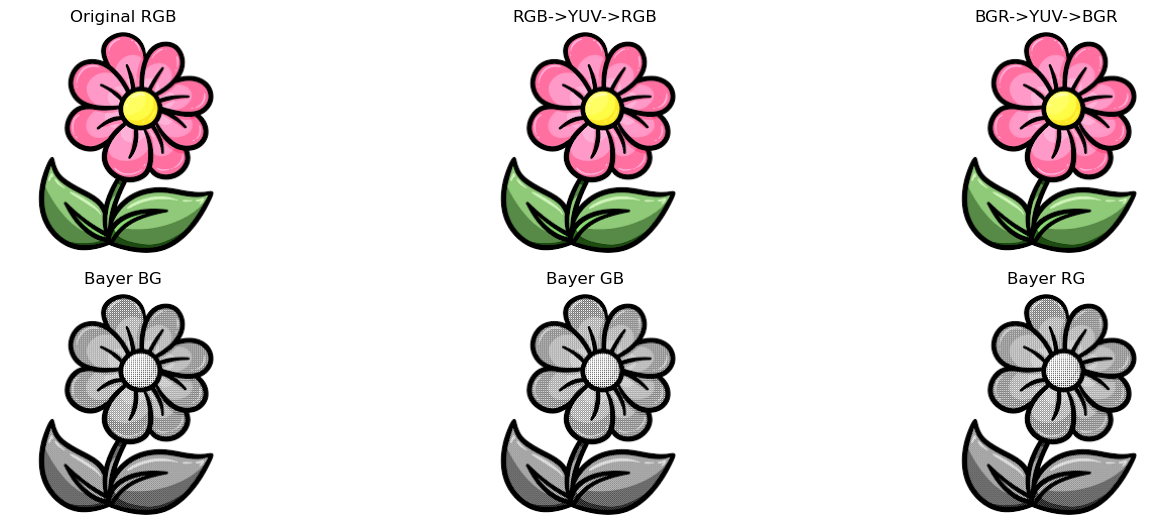

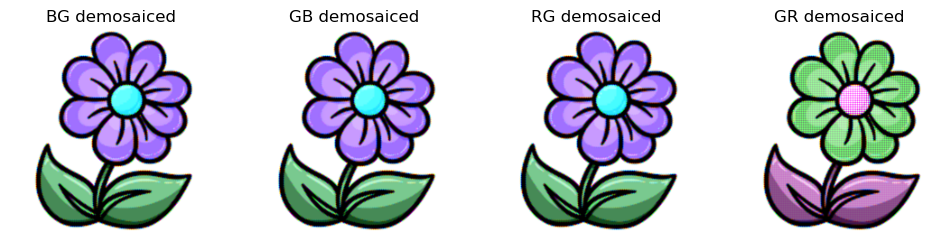

In [8]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_path = 'flor.jpg'
bgr = cv2.imread(img_path, cv2.IMREAD_COLOR)  # OpenCV lee en BGR

h, w = bgr.shape[:2]

def make_bayer(bgr_img, pattern):
    # pattern: 'BG','GB','RG','GR' 
    bayer = np.zeros((h, w), dtype=np.uint8)
    B = bgr_img[..., 0]; G = bgr_img[..., 1]; R = bgr_img[..., 2]
    if pattern == 'BG':
        bayer[0::2,0::2] = B[0::2,0::2]
        bayer[0::2,1::2] = G[0::2,1::2]
        bayer[1::2,0::2] = G[1::2,0::2]
        bayer[1::2,1::2] = R[1::2,1::2]
    elif pattern == 'GB':
        bayer[0::2,0::2] = G[0::2,0::2]
        bayer[0::2,1::2] = B[0::2,1::2]
        bayer[1::2,0::2] = R[1::2,0::2]
        bayer[1::2,1::2] = G[1::2,1::2]
    elif pattern == 'RG':
        bayer[0::2,0::2] = R[0::2,0::2]
        bayer[0::2,1::2] = G[0::2,1::2]
        bayer[1::2,0::2] = G[1::2,0::2]
        bayer[1::2,1::2] = B[1::2,1::2]
    elif pattern == 'GR':
        bayer[0::2,0::2] = G[0::2,0::2]
        bayer[0::2,1::2] = R[0::2,1::2]
        bayer[1::2,0::2] = B[1::2,0::2]
        bayer[1::2,1::2] = G[1::2,1::2]
    else:
        raise ValueError("pattern debe ser uno de: 'BG','GB','RG','GR'")
    return bayer

# detectar flags Bayer disponibles en cv2
candidates = [
    'COLOR_BayerBG2BGR','COLOR_BayerGB2BGR','COLOR_BayerRG2BGR','COLOR_BayerGR2BGR',
    'COLOR_BayerBG2RGB','COLOR_BayerGB2RGB','COLOR_BayerRG2RGB','COLOR_BayerGR2RGB',
    'COLOR_BayerBG2BGR_VNG','COLOR_BayerGB2BGR_VNG','COLOR_BayerRG2BGR_VNG','COLOR_BayerGR2BGR_VNG'
]
flags = [name for name in candidates if hasattr(cv2, name)]

# patrones a probar
patterns = {'BG':'BG','GB':'GB','RG':'RG','GR':'GR'}

results = {}
for pname, code in patterns.items():
    bayer = make_bayer(bgr, code)
    demosaics = {}
    for flag_name in flags:
        # elegir solo flags que contienen el patrón letters (BG,GB,RG,GR) or generic
        if pname in flag_name or all(p not in flag_name for p in patterns.keys()):
            flag = getattr(cv2, flag_name)
            try:
                out = cv2.cvtColor(bayer, flag)
                demosaics[flag_name] = out
            except Exception:
                pass
    results[pname] = (bayer, demosaics)

# conversiones RGB <-> YUV (usar RGB ordering para el usuario)
rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
rgb2yuv = cv2.cvtColor(rgb, cv2.COLOR_RGB2YUV)
yuv2rgb = cv2.cvtColor(rgb2yuv, cv2.COLOR_YUV2RGB)

# también BGR <-> YUV (OpenCV estándar)
bgr2yuv = cv2.cvtColor(bgr, cv2.COLOR_BGR2YUV)
yuv2bgr = cv2.cvtColor(bgr2yuv, cv2.COLOR_YUV2BGR)

# mostrar resultados
plt.figure(figsize=(14, 8))
plt.subplot(3, 3, 1); plt.imshow(rgb); plt.title('Original RGB'); plt.axis('off')
plt.subplot(3, 3, 2); plt.imshow(cv2.cvtColor(rgb2yuv, cv2.COLOR_YUV2RGB)); plt.title('RGB->YUV->RGB'); plt.axis('off')
plt.subplot(3, 3, 3); plt.imshow(cv2.cvtColor(bgr2yuv, cv2.COLOR_YUV2BGR)[:,:,::-1]); plt.title('BGR->YUV->BGR'); plt.axis('off')

# mostrar un patrón Bayer + uno o dos demosaics (los disponibles)
row = 2
col = 1
for pname, (bayer, demosaics) in results.items():
    plt.subplot(3, 3, 3 + col); plt.imshow(bayer, cmap='gray'); plt.title(f'Bayer {pname}'); plt.axis('off')
    col += 1
    if col > 3: break

plt.tight_layout()
plt.show()

# mostrar primero demosaiced por patrón  versión corregida
n = len(results)                # usar tantas columnas como patrones 
plt.figure(figsize=(3*n, 3))
for i, (pname, (bayer, demosaics)) in enumerate(results.items(), start=1):
    if demosaics:
        img = next(iter(demosaics.values()))
        plt.subplot(1, n, i)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title(f'{pname} demosaiced')
        plt.axis('off')
    else:
        plt.subplot(1, n, i)
        plt.imshow(bayer, cmap='gray')
        plt.title(f'{pname} (sin dem)')
        plt.axis('off')
plt.show()

# guardar demosaiced para inspección
out_dir = os.path.join(os.path.dirname(img_path), 'bayer_outputs')
os.makedirs(out_dir, exist_ok=True)
for pname, (bayer, demosaics) in results.items():
    for flag_name, img_out in demosaics.items():
        fname = f'{pname}_{flag_name}.png'
        cv2.imwrite(os.path.join(out_dir, fname), img_out)

Parte 2 Umbralizacion

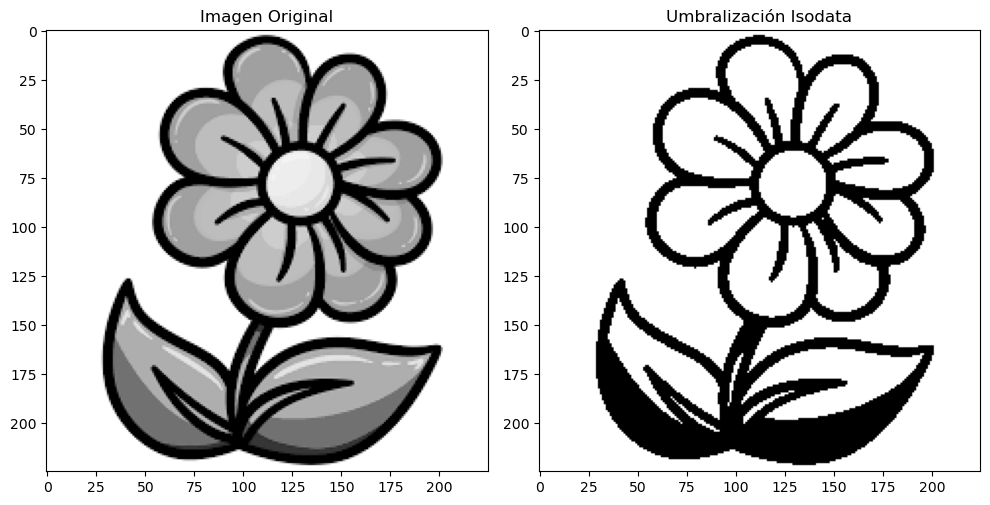

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def isodata (image):
    #decidimos umbral incial de 0 a 25
    umbral=128 #puedo cambiar cuando se requiera
    while True:
        grupo1=image[image<=umbral]#grupo donde el umbral es menor o igual al umbral
        grupo2=image[image>umbral]#grupo donde el umbral es mayor al umbral
        #calculo la media de cada grupo
        media1=np.mean(grupo1)
        media2=np.mean(grupo2)
        #calculamos el nuevo valor del umbral
        nuevo_umbral=(media1+media2)/2
        #si el nuevo umbral es igual al anterior, salimos del ciclo
        if nuevo_umbral==umbral:
            break
        umbral=nuevo_umbral
    return umbral
imagen=cv2.imread('flor.jpg',0)
umbral_isodata=isodata(imagen)
_,umbralizacion_isodata=cv2.threshold(imagen,umbral_isodata,255,cv2.THRESH_BINARY)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title('Imagen Original')
plt.imshow(imagen,cmap='gray')
plt.subplot(1,2,2)
plt.title('Umbralización Isodata')
plt.imshow(umbralizacion_isodata,cmap='gray')
plt.tight_layout()
plt.show()

Umbralizacion de dos picos

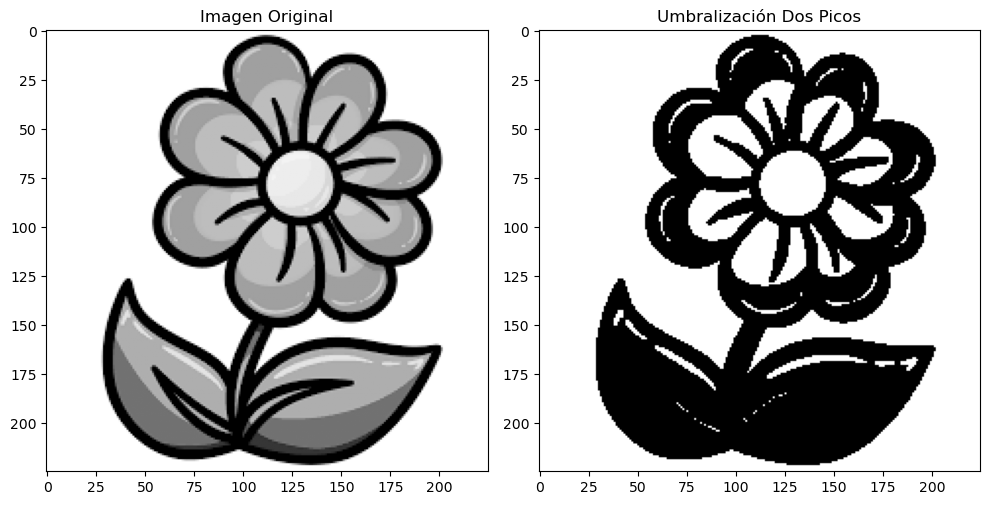

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def dos_picos(image):
    #calculo de histograma
    hist = cv2.calcHist([image], [0], None, [256], [0, 256]).flatten()#calcula el histograma de la imagen y lo aplana a un array unidimensional
    #seleccionamos los dos picos 
    pico=np.array(hist)
    pico=pico.flatten()
    pico_dif=np.diff(pico)#diferencia entre picos
    primer_pico=np.argmax(pico_dif[:128])#pico hasta 127
    segundo_pico=np.argmax(pico_dif[128:])+128#pico desde 128 para adelante
    #calculo umbral
    umbral=int((primer_pico+segundo_pico)/2)
    return umbral
imagen=cv2.imread('flor.jpg',0)
umbral_dos_picos=dos_picos(imagen)
_,nueva=cv2.threshold(imagen,umbral_dos_picos,255,cv2.THRESH_BINARY)
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title('Imagen Original')
plt.imshow(imagen,cmap='gray')
plt.subplot(1,2,2)
plt.title('Umbralización Dos Picos')
plt.imshow(nueva,cmap='gray')
plt.tight_layout()
plt.show()

Umbralizacion OTSU

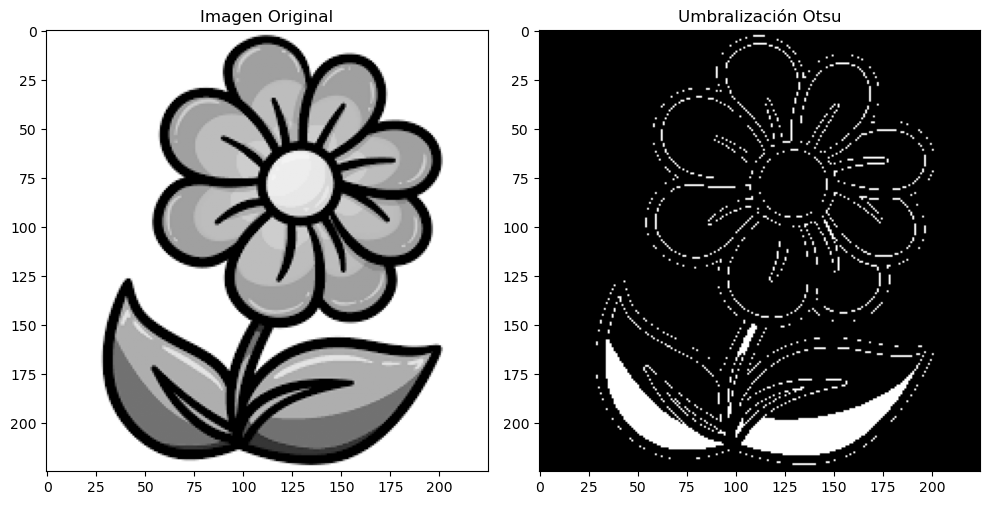

In [4]:
import cv2
from matplotlib import image
import numpy as np
import matplotlib.pyplot as plt

imagen=cv2.imread('flor.jpg',0)#escala de grises
_,otsu=cv2.threshold(imagen,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)#se puede combinar entre diferentes tipos de umbralizacion
imagen_fin=np.where(imagen>otsu,255,0).astype(np.uint8)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title('Imagen Original')
plt.imshow(imagen,cmap='gray')
plt.subplot(1,2,2)
plt.title('Umbralización Otsu')
plt.imshow(imagen_fin,cmap='gray')
plt.tight_layout()
plt.show()

Umbralizacion Variable Participon de una Imagen

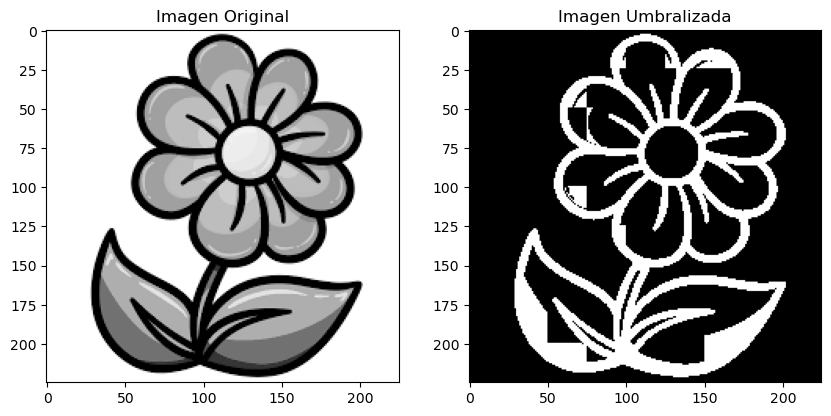

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def variable_part(image,tam_bloque,c):
    umbral_img=np.zeros_like(image)
    for y in range (0, image.shape[0], tam_bloque):#recoremos filas
        for x in range(0, image.shape[1], tam_bloque):#recoremos columnas
            bloque = image[y:y+tam_bloque, x:x+tam_bloque]#vemos el bloque de la imagen
            bloq_media=np.mean(bloque)#calculo la media del bloque
            umbral=bloq_media-c#calculo el umbral sumando la media del bloque con una constante
            umbral_img[y:y+tam_bloque, x:x+tam_bloque]=(bloque>umbral)+255

    return umbral_img
tam_b=25
c=10
imagen=cv2.imread('flor.jpg',0)
img_fin=variable_part(imagen,tam_b,c)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title('Imagen Original')
plt.imshow(imagen,cmap='gray')
plt.subplot(1,2,2)
plt.title('Imagen Umbralizada')
plt.imshow(img_fin,cmap='gray')

Propiedades locales

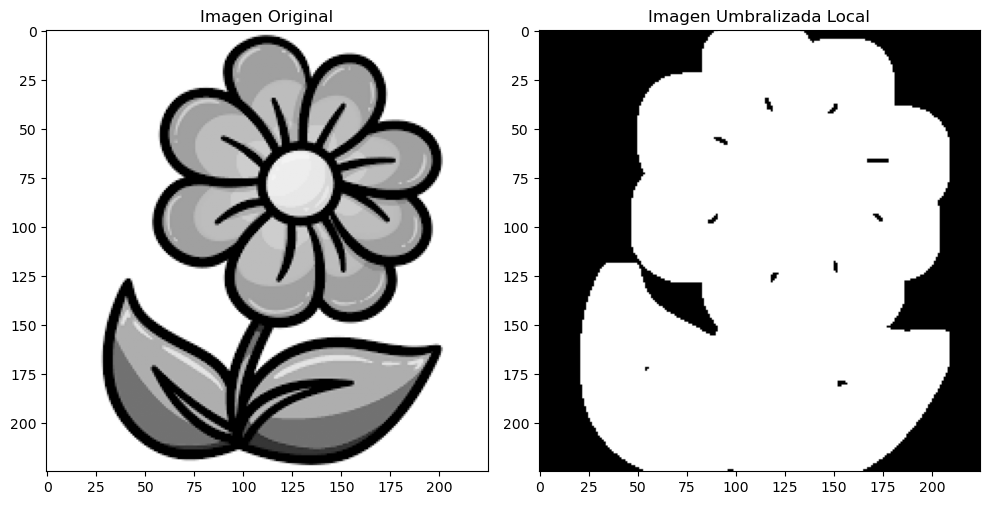

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image=cv2.imread('flor.jpg',0)#escala de grises
def local (iamge,tamanio_ventana,k):
    umbr_img=np.zeros_like(image)
    #definir un rastreo de imagen padding
    pad=tamanio_ventana//2
    padded_image=cv2.copyMakeBorder(image,pad,pad,pad,pad,cv2.BORDER_REPLICATE)
    for y in range(image.shape[0]):
        for x in range(image.shape[1]):
            ventana=padded_image[y:y+tamanio_ventana,x:x+tamanio_ventana]#ventana de la imagen
            mean_local=np.mean(ventana)#calculo la media de la ventana
            std_mean=np.std(ventana)#calculo la desviacion estandar de la ventana
            umbral=mean_local-(k*std_mean)
            umbr_img[y,x]=255 if image[y,x]>umbral else 0
    return umbr_img
tam_vent=15
k=2
img_fin=local(image,tam_vent,k)
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title('Imagen Original')
plt.imshow(image,cmap='gray')
plt.subplot(1,2,2)
plt.title('Imagen Umbralizada Local')
plt.imshow(img_fin,cmap='gray')
plt.tight_layout()
plt.show()

Variable con opcv

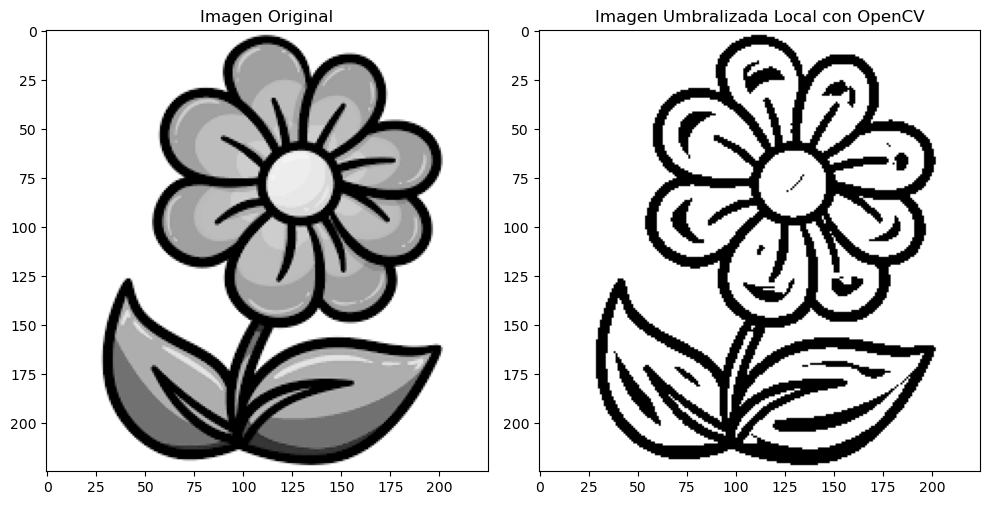

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image=cv2.imread('flor.jpg',0)

ventana=15
k=2
imagen_fin=cv2.adaptiveThreshold(image,255,cv2.ADAPTIVE_THRESH_MEAN_C,cv2.THRESH_BINARY,ventana,k)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title('Imagen Original')
plt.imshow(image,cmap='gray')
plt.subplot(1,2,2)
plt.title('Imagen Umbralizada Local con OpenCV')
plt.imshow(imagen_fin,cmap='gray')
plt.tight_layout()
plt.show()

Formula OTSU

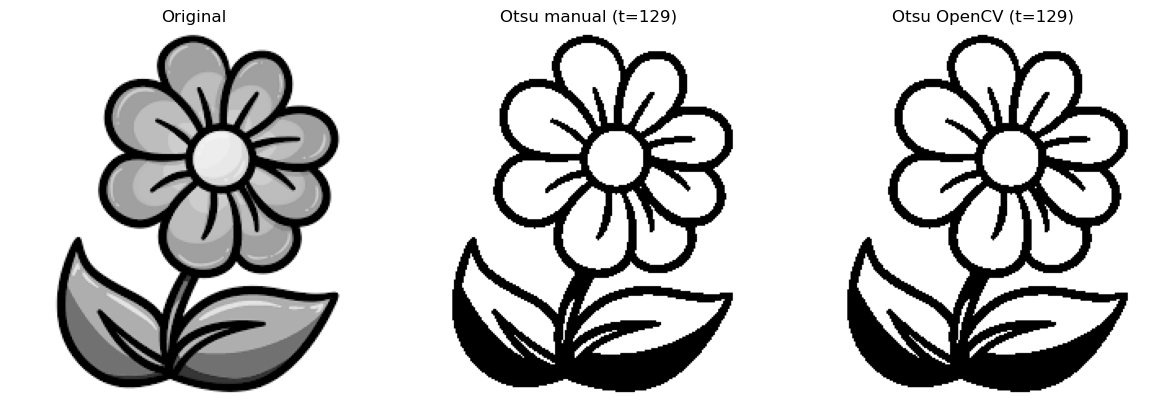

In [8]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def otsu_manual(image):
    hist = cv2.calcHist([image], [0], None, [256], [0, 256]).flatten()
    total = image.size
    sum_total = np.dot(np.arange(256), hist)
    w0 = 0.0
    sumB = 0.0
    max_between = 0.0
    threshold = 0
    for t in range(256):
        w0 += hist[t]
        if w0 == 0:
            continue
        w1 = total - w0
        if w1 == 0:
            break
        sumB += t * hist[t]
        mu0 = sumB / w0
        mu1 = (sum_total - sumB) / w1
        # aplicamos la fórmula
        between = (w0/total) * (w1/total) * (mu0 - mu1) ** 2
        if between > max_between:
            max_between = between
            threshold = t
    return threshold, max_between

imagen = cv2.imread('flor.jpg', 0)

t_manual, val = otsu_manual(imagen)
t_cv, bin_cv = cv2.threshold(imagen, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
_, bin_manual = cv2.threshold(imagen, t_manual, 255, cv2.THRESH_BINARY)
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(imagen, cmap='gray'); plt.title('Original'); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(bin_manual, cmap='gray'); plt.title(f'Otsu manual (t={t_manual})'); plt.axis('off')
plt.subplot(1,3,3); plt.imshow(bin_cv, cmap='gray'); plt.title(f'Otsu OpenCV (t={int(t_cv)})'); plt.axis('off')
plt.tight_layout()
plt.show()